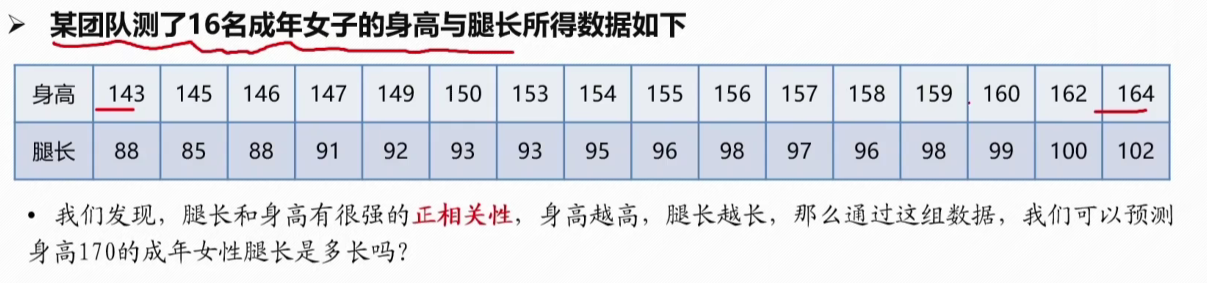

系数 b: [-16.07298073   0.71935219]
置信区间 bint: [[-33.70714783   1.56118637]
 [  0.60465767   0.83404672]]
统计量 (R², F, p): (np.float64(0.928187845952738), np.float64(13.451879848726044), np.float64(2.131162895241853e-09))


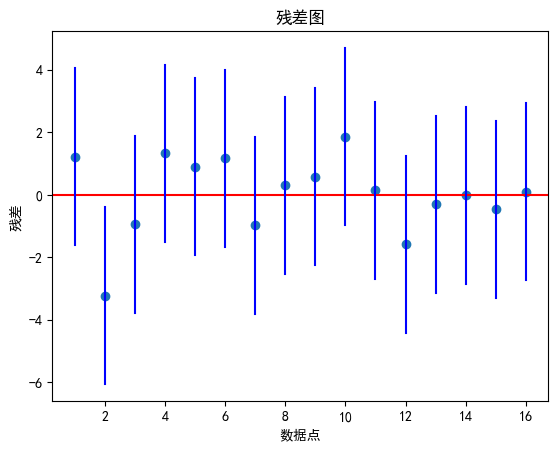

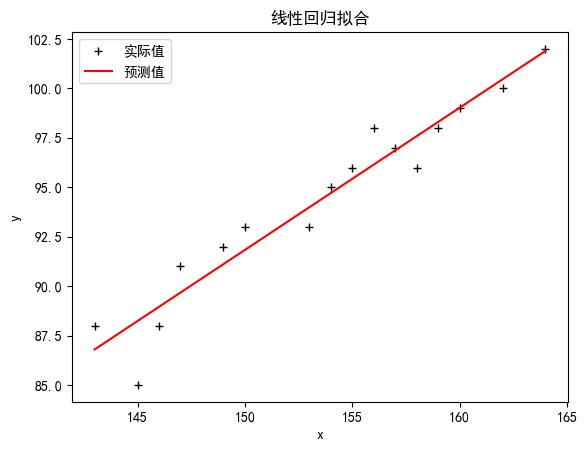

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans', 'Arial Unicode MS', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 1、输入数据
# 输入X的样本值
x = np.array([143, 145, 146, 147, 149, 150, 153, 154, 155, 156, 157, 158, 159, 160, 162, 164])
# 插入\beta0对应列
X = np.column_stack((np.ones(16), x))
# 输入Y的样本值
Y = np.array([88, 85, 88, 91, 92, 93, 93, 95, 96, 98, 97, 96, 98, 99, 100, 102])

# 2、回归分析及检验
# 使用最小二乘法进行线性回归
result = stats.linregress(x, Y)
# 提取斜率和截距
b1 = result.slope
b0 = result.intercept
b = np.array([b0, b1])

# 计算置信区间
# 对于截距和斜率的置信区间
confidence_level = 0.95
df = len(x) - 2  # 自由度
t_value = stats.t.ppf((1 + confidence_level) / 2, df)

# 截距的置信区间
b0_se = result.intercept_stderr
b0_ci = (b0 - t_value * b0_se, b0 + t_value * b0_se)

# 斜率的置信区间
b1_se = result.stderr
b1_ci = (b1 - t_value * b1_se, b1 + t_value * b1_se)

bint = np.array([b0_ci, b1_ci])

# 计算R²等统计量
r_squared = result.rvalue ** 2
# F统计量和p值
f_value = result.slope / result.stderr
p_value = result.pvalue

stats_summary = (r_squared, f_value, p_value)

# 输出我们需要的数据
print("系数 b:", b)
print("置信区间 bint:", bint)
print("统计量 (R², F, p):", stats_summary)

# 3、残差分析，做残差图
# 计算预测值
z = b0 + b1 * x
# 计算残差
r = Y - z

# 计算残差的置信区间
# 残差的标准误
r_se = np.sqrt(np.sum(r**2) / df)
# 残差的置信区间
r_ci = np.column_stack((r - t_value * r_se, r + t_value * r_se))

# 绘制残差图
fig, ax = plt.subplots()
ax.plot(range(1, len(r)+1), r, 'o')
ax.axhline(y=0, color='r', linestyle='-')
for i in range(len(r)):
    ax.plot([i+1, i+1], [r_ci[i, 0], r_ci[i, 1]], 'b-')
ax.set_xlabel('数据点')
ax.set_ylabel('残差')
ax.set_title('残差图')
plt.show()

# 4、预测及作图
plt.figure()
plt.plot(x, Y, 'k+', label='实际值')
plt.plot(x, z, 'r', label='预测值')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('线性回归拟合')
plt.show()